# Phase 3 — Exploratory Analysis: When and Why This Household Uses Power

   Answers business questions 1 (when is consumption highest?) and
   2 (which circuits drive it?). Aggregations are done in both SQL and pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# pandas copy (timestamp is the index)
df = pd.read_parquet("../data/processed/power_readings_clean.parquet")

# database connection for running SQL
engine = create_engine("sqlite:///../powerpulse.db")

print(df.shape)
df.head()

(2075259, 10)


,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3,total_wh,submeter_sum_wh,unmetered_wh
reading_ts,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,70.266667,18.0,52.266667
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,89.333333,17.0,72.333333
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,89.566667,19.0,70.566667
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,89.800000,18.0,71.800000
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,61.100000,18.0,43.100000


In [2]:
load_curve = pd.read_sql("""
    SELECT strftime('%H', reading_ts) AS hour_of_day,
           ROUND(AVG(global_active_power), 3) AS avg_active_kw
    FROM power_readings_clean
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""", engine)
load_curve

,hour_of_day,avg_active_kw
0,00,0.659
1,01,0.539
2,02,0.481
3,03,0.445
4,04,0.444
5,05,0.454
6,06,0.792
7,07,1.502
8,08,1.461
9,09,1.332


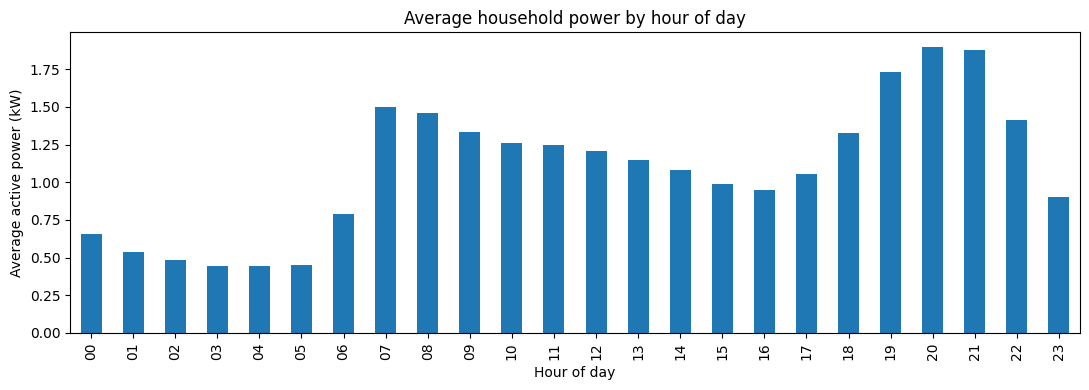

In [3]:
ax = load_curve.plot(x="hour_of_day", y="avg_active_kw", kind="bar",
                     figsize=(11, 4), legend=False)
ax.set_title("Average household power by hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average active power (kW)")
plt.tight_layout()
plt.savefig("../reports/figures/load_curve_by_hour.png", dpi=120)
plt.show()

In [4]:
load_curve_pd = df.groupby(df.index.hour)["global_active_power"].mean()
load_curve_pd

reading_ts
0     0.659434
1     0.539325
2     0.480618
3     0.444866
4     0.443847
5     0.453674
6     0.791631
7     1.502264
8     1.461049
9     1.331643
10    1.260751
11    1.245797
12    1.207076
13    1.144538
14    1.082881
15    0.990815
16    0.948942
17    1.055290
18    1.326465
19    1.733347
20    1.899103
21    1.877786
22    1.412674
23    0.902142
Name: global_active_power, dtype: float64

In [5]:
day_type = pd.read_sql("""
    SELECT CASE WHEN strftime('%w', reading_ts) IN ('0','6')
                THEN 'weekend' ELSE 'weekday' END AS day_type,
           ROUND(AVG(global_active_power), 3) AS avg_active_kw
    FROM power_readings_clean
    GROUP BY day_type
""", engine)
day_type

,day_type,avg_active_kw
0,weekday,1.036
1,weekend,1.234


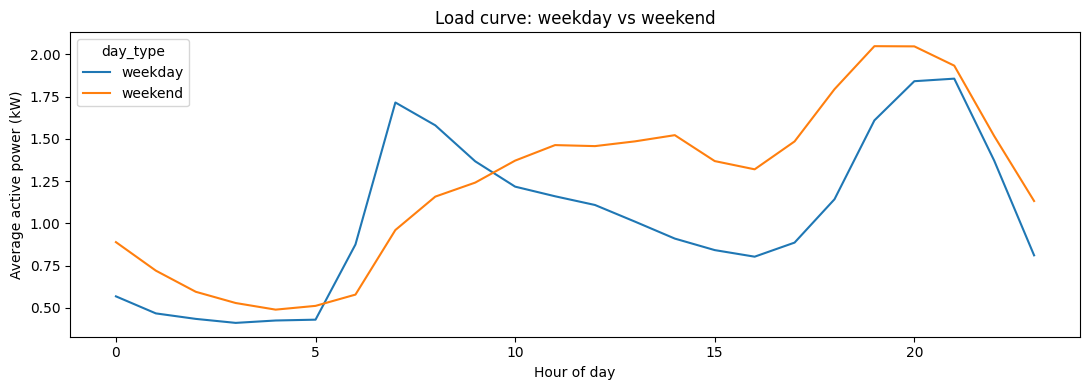

In [6]:
df["day_type"] = np.where(df.index.dayofweek >= 5, "weekend", "weekday")
pivot = df.pivot_table(values="global_active_power",
                       index=df.index.hour, columns="day_type", aggfunc="mean")
ax = pivot.plot(figsize=(11, 4))
ax.set_title("Load curve: weekday vs weekend")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Average active power (kW)")
plt.tight_layout()
plt.savefig("../reports/figures/load_curve_weekday_weekend.png", dpi=120)
plt.show()

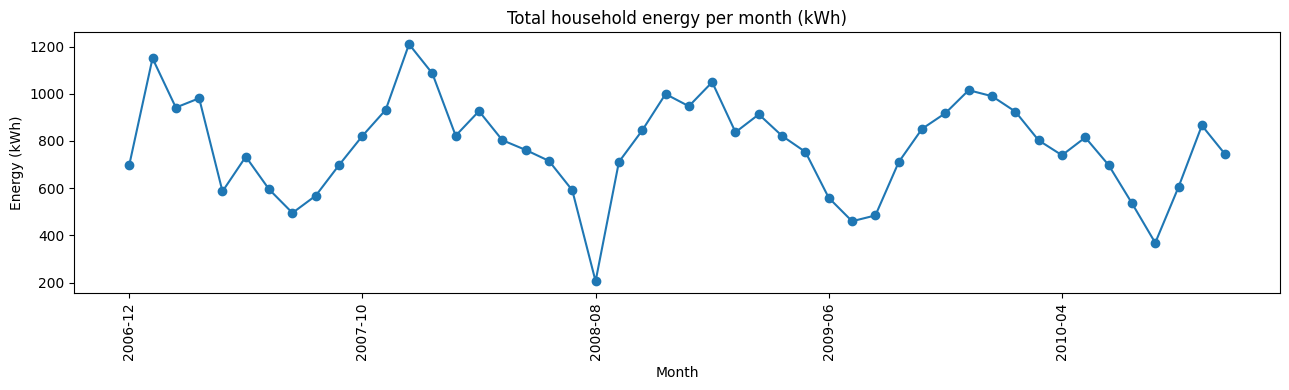

In [7]:
monthly = pd.read_sql("""
    SELECT strftime('%Y-%m', reading_ts) AS month,
           ROUND(SUM(total_wh) / 1000.0, 1) AS total_kwh
    FROM power_readings_clean
    GROUP BY month ORDER BY month
""", engine)

ax = monthly.plot(x="month", y="total_kwh", figsize=(13, 4), legend=False, marker="o")
ax.set_title("Total household energy per month (kWh)")
ax.set_xlabel("Month"); ax.set_ylabel("Energy (kWh)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../reports/figures/monthly_energy_trend.png", dpi=120)
plt.show()

In [8]:
breakdown = pd.read_sql("""
    SELECT ROUND(SUM(sub_metering_1) / 1000.0, 1) AS kitchen_kwh,
           ROUND(SUM(sub_metering_2) / 1000.0, 1) AS laundry_kwh,
           ROUND(SUM(sub_metering_3) / 1000.0, 1) AS water_heater_ac_kwh,
           ROUND(SUM(unmetered_wh)  / 1000.0, 1) AS unmetered_kwh
    FROM power_readings_clean
""", engine)
breakdown

,kitchen_kwh,laundry_kwh,water_heater_ac_kwh,unmetered_kwh
0,2299.3,2661.3,13235.9,19090.1


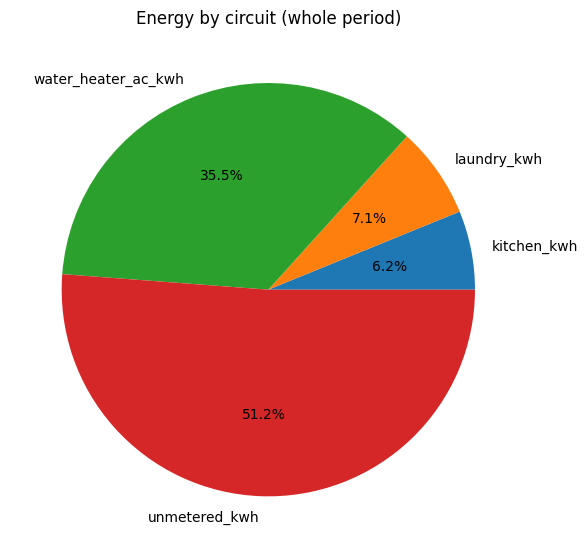

,kwh,pct
kitchen_kwh,2299.3,6.2
laundry_kwh,2661.3,7.1
water_heater_ac_kwh,13235.9,35.5
unmetered_kwh,19090.1,51.2


In [9]:
shares = breakdown.T.rename(columns={0: "kwh"})
shares["pct"] = (shares["kwh"] / shares["kwh"].sum() * 100).round(1)
ax = shares["kwh"].plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6),
                        ylabel="", title="Energy by circuit (whole period)")
plt.tight_layout()
plt.savefig("../reports/figures/energy_by_circuit.png", dpi=120)
plt.show()
shares